In [10]:
"""
08_baselines.ipynb
Baseline модели + сравнение с трансформером
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline

# Загрузка данных
train_df = pd.read_csv("../data/final/train_boosted.csv")
test_df = pd.read_csv("../data/final/test.csv")

X_train = train_df['text'].values
y_train = train_df['category'].values
X_test = test_df['text'].values
y_test = test_df['category'].values

CATEGORIES = sorted(train_df['category'].unique().tolist())

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Категорий: {len(CATEGORIES)}")
print(f"\nTrain распределение:")
print(train_df['category'].value_counts().sort_index().to_string())

Train: 2519, Test: 581
Категорий: 10

Train распределение:
category
account            256
delivery           254
general_info       250
order_status       256
other              256
payment_refund     257
product_info       257
promo_loyalty      233
return_exchange    256
technical_issue    244


In [11]:
"""
Baseline 1: TF-IDF + Logistic Regression
"""
print("=" * 60)
print("📊 BASELINE 1: TF-IDF + Logistic Regression")
print("=" * 60)

start = time.time()

# Pipeline
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        random_state=42
    ))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

train_time_lr = time.time() - start

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_macro_lr = f1_score(y_test, y_pred_lr, average='macro')
f1_weighted_lr = f1_score(y_test, y_pred_lr, average='weighted')

print(f"\n  ⏱️  Время обучения:   {train_time_lr:.2f}s")
print(f"  🎯 Accuracy:          {acc_lr:.3f}")
print(f"  📊 Macro F1:          {f1_macro_lr:.3f}")
print(f"  📊 Weighted F1:       {f1_weighted_lr:.3f}")
print(f"\n{classification_report(y_test, y_pred_lr, target_names=CATEGORIES, digits=3)}")

📊 BASELINE 1: TF-IDF + Logistic Regression

  ⏱️  Время обучения:   0.58s
  🎯 Accuracy:          0.914
  📊 Macro F1:          0.914
  📊 Weighted F1:       0.914

                 precision    recall  f1-score   support

        account      0.906     0.967     0.935        60
       delivery      0.915     0.931     0.923        58
   general_info      0.960     0.842     0.897        57
   order_status      0.963     0.881     0.920        59
          other      0.918     0.949     0.933        59
 payment_refund      0.850     0.850     0.850        60
   product_info      0.895     0.850     0.872        60
  promo_loyalty      0.927     0.962     0.944        53
return_exchange      0.859     0.932     0.894        59
technical_issue      0.965     0.982     0.973        56

       accuracy                          0.914       581
      macro avg      0.916     0.915     0.914       581
   weighted avg      0.915     0.914     0.914       581



In [12]:
"""
Baseline 2a: TF-IDF + Linear SVM
Baseline 2b: TF-IDF + Random Forest
"""

# ── SVM ──
print("=" * 60)
print("📊 BASELINE 2a: TF-IDF + Linear SVM")
print("=" * 60)

start = time.time()

pipe_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', LinearSVC(C=1.0, max_iter=2000, random_state=42))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
train_time_svm = time.time() - start

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_macro_svm = f1_score(y_test, y_pred_svm, average='macro')
f1_weighted_svm = f1_score(y_test, y_pred_svm, average='weighted')

print(f"\n  ⏱️  Время обучения:   {train_time_svm:.2f}s")
print(f"  🎯 Accuracy:          {acc_svm:.3f}")
print(f"  📊 Macro F1:          {f1_macro_svm:.3f}")
print(f"  📊 Weighted F1:       {f1_weighted_svm:.3f}")
print(f"\n{classification_report(y_test, y_pred_svm, target_names=CATEGORIES, digits=3)}")

# ── Random Forest ──
print("=" * 60)
print("📊 BASELINE 2b: TF-IDF + Random Forest")
print("=" * 60)

start = time.time()

pipe_rf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
train_time_rf = time.time() - start

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\n  ⏱️  Время обучения:   {train_time_rf:.2f}s")
print(f"  🎯 Accuracy:          {acc_rf:.3f}")
print(f"  📊 Macro F1:          {f1_macro_rf:.3f}")
print(f"  📊 Weighted F1:       {f1_weighted_rf:.3f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=CATEGORIES, digits=3)}")

📊 BASELINE 2a: TF-IDF + Linear SVM

  ⏱️  Время обучения:   0.17s
  🎯 Accuracy:          0.947
  📊 Macro F1:          0.947
  📊 Weighted F1:       0.946

                 precision    recall  f1-score   support

        account      1.000     0.983     0.992        60
       delivery      0.949     0.966     0.957        58
   general_info      0.945     0.912     0.929        57
   order_status      0.967     1.000     0.983        59
          other      0.889     0.949     0.918        59
 payment_refund      0.948     0.917     0.932        60
   product_info      0.891     0.817     0.852        60
  promo_loyalty      1.000     0.981     0.990        53
return_exchange      0.905     0.966     0.934        59
technical_issue      0.982     0.982     0.982        56

       accuracy                          0.947       581
      macro avg      0.948     0.947     0.947       581
   weighted avg      0.947     0.947     0.946       581

📊 BASELINE 2b: TF-IDF + Random Forest

  ⏱️  

In [13]:
"""
Baseline 3: TF-IDF + MLP Neural Network
"""
print("=" * 60)
print("📊 BASELINE 3: TF-IDF + MLP Neural Network")
print("=" * 60)

start = time.time()

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp.fit(X_train_tfidf, y_train_encoded)
y_pred_mlp_encoded = mlp.predict(X_test_tfidf)
y_pred_mlp = le.inverse_transform(y_pred_mlp_encoded)

train_time_mlp = time.time() - start

acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_macro_mlp = f1_score(y_test, y_pred_mlp, average='macro')
f1_weighted_mlp = f1_score(y_test, y_pred_mlp, average='weighted')

print(f"\n  ⏱️  Время обучения:   {train_time_mlp:.2f}s")
print(f"  🎯 Accuracy:          {acc_mlp:.3f}")
print(f"  📊 Macro F1:          {f1_macro_mlp:.3f}")
print(f"  📊 Weighted F1:       {f1_weighted_mlp:.3f}")
print(f"\n{classification_report(y_test, y_pred_mlp, target_names=CATEGORIES, digits=3)}")

📊 BASELINE 3: TF-IDF + MLP Neural Network

  ⏱️  Время обучения:   23.26s
  🎯 Accuracy:          0.936
  📊 Macro F1:          0.937
  📊 Weighted F1:       0.936

                 precision    recall  f1-score   support

        account      1.000     0.967     0.983        60
       delivery      0.947     0.931     0.939        58
   general_info      0.927     0.895     0.911        57
   order_status      0.951     0.983     0.967        59
          other      0.879     0.983     0.928        59
 payment_refund      0.946     0.883     0.914        60
   product_info      0.895     0.850     0.872        60
  promo_loyalty      0.962     0.962     0.962        53
return_exchange      0.902     0.932     0.917        59
technical_issue      0.965     0.982     0.973        56

       accuracy                          0.936       581
      macro avg      0.937     0.937     0.937       581
   weighted avg      0.937     0.936     0.936       581



In [14]:
"""
Сводная таблица baseline моделей
"""
results_baseline = pd.DataFrame([
    {"Модель": "TF-IDF + LogReg",      "Accuracy": acc_lr,  "Macro F1": f1_macro_lr,  "Weighted F1": f1_weighted_lr,  "Время (с)": train_time_lr},
    {"Модель": "TF-IDF + SVM",         "Accuracy": acc_svm, "Macro F1": f1_macro_svm, "Weighted F1": f1_weighted_svm, "Время (с)": train_time_svm},
    {"Модель": "TF-IDF + RandomForest", "Accuracy": acc_rf,  "Macro F1": f1_macro_rf,  "Weighted F1": f1_weighted_rf,  "Время (с)": train_time_rf},
    {"Модель": "TF-IDF + MLP",         "Accuracy": acc_mlp, "Macro F1": f1_macro_mlp, "Weighted F1": f1_weighted_mlp, "Время (с)": train_time_mlp},
])

print("=" * 70)
print("📊 СВОДНАЯ ТАБЛИЦА BASELINE МОДЕЛЕЙ")
print("=" * 70)
print(results_baseline.to_string(index=False, float_format="%.3f"))

# Лучшая baseline
best_baseline = results_baseline.loc[results_baseline['Macro F1'].idxmax()]
print(f"\n🏆 Лучшая baseline: {best_baseline['Модель']} (F1: {best_baseline['Macro F1']:.3f})")

📊 СВОДНАЯ ТАБЛИЦА BASELINE МОДЕЛЕЙ
               Модель  Accuracy  Macro F1  Weighted F1  Время (с)
      TF-IDF + LogReg     0.914     0.914        0.914      0.585
         TF-IDF + SVM     0.947     0.947        0.946      0.166
TF-IDF + RandomForest     0.871     0.873        0.873      1.085
         TF-IDF + MLP     0.936     0.937        0.936     23.258

🏆 Лучшая baseline: TF-IDF + SVM (F1: 0.947)


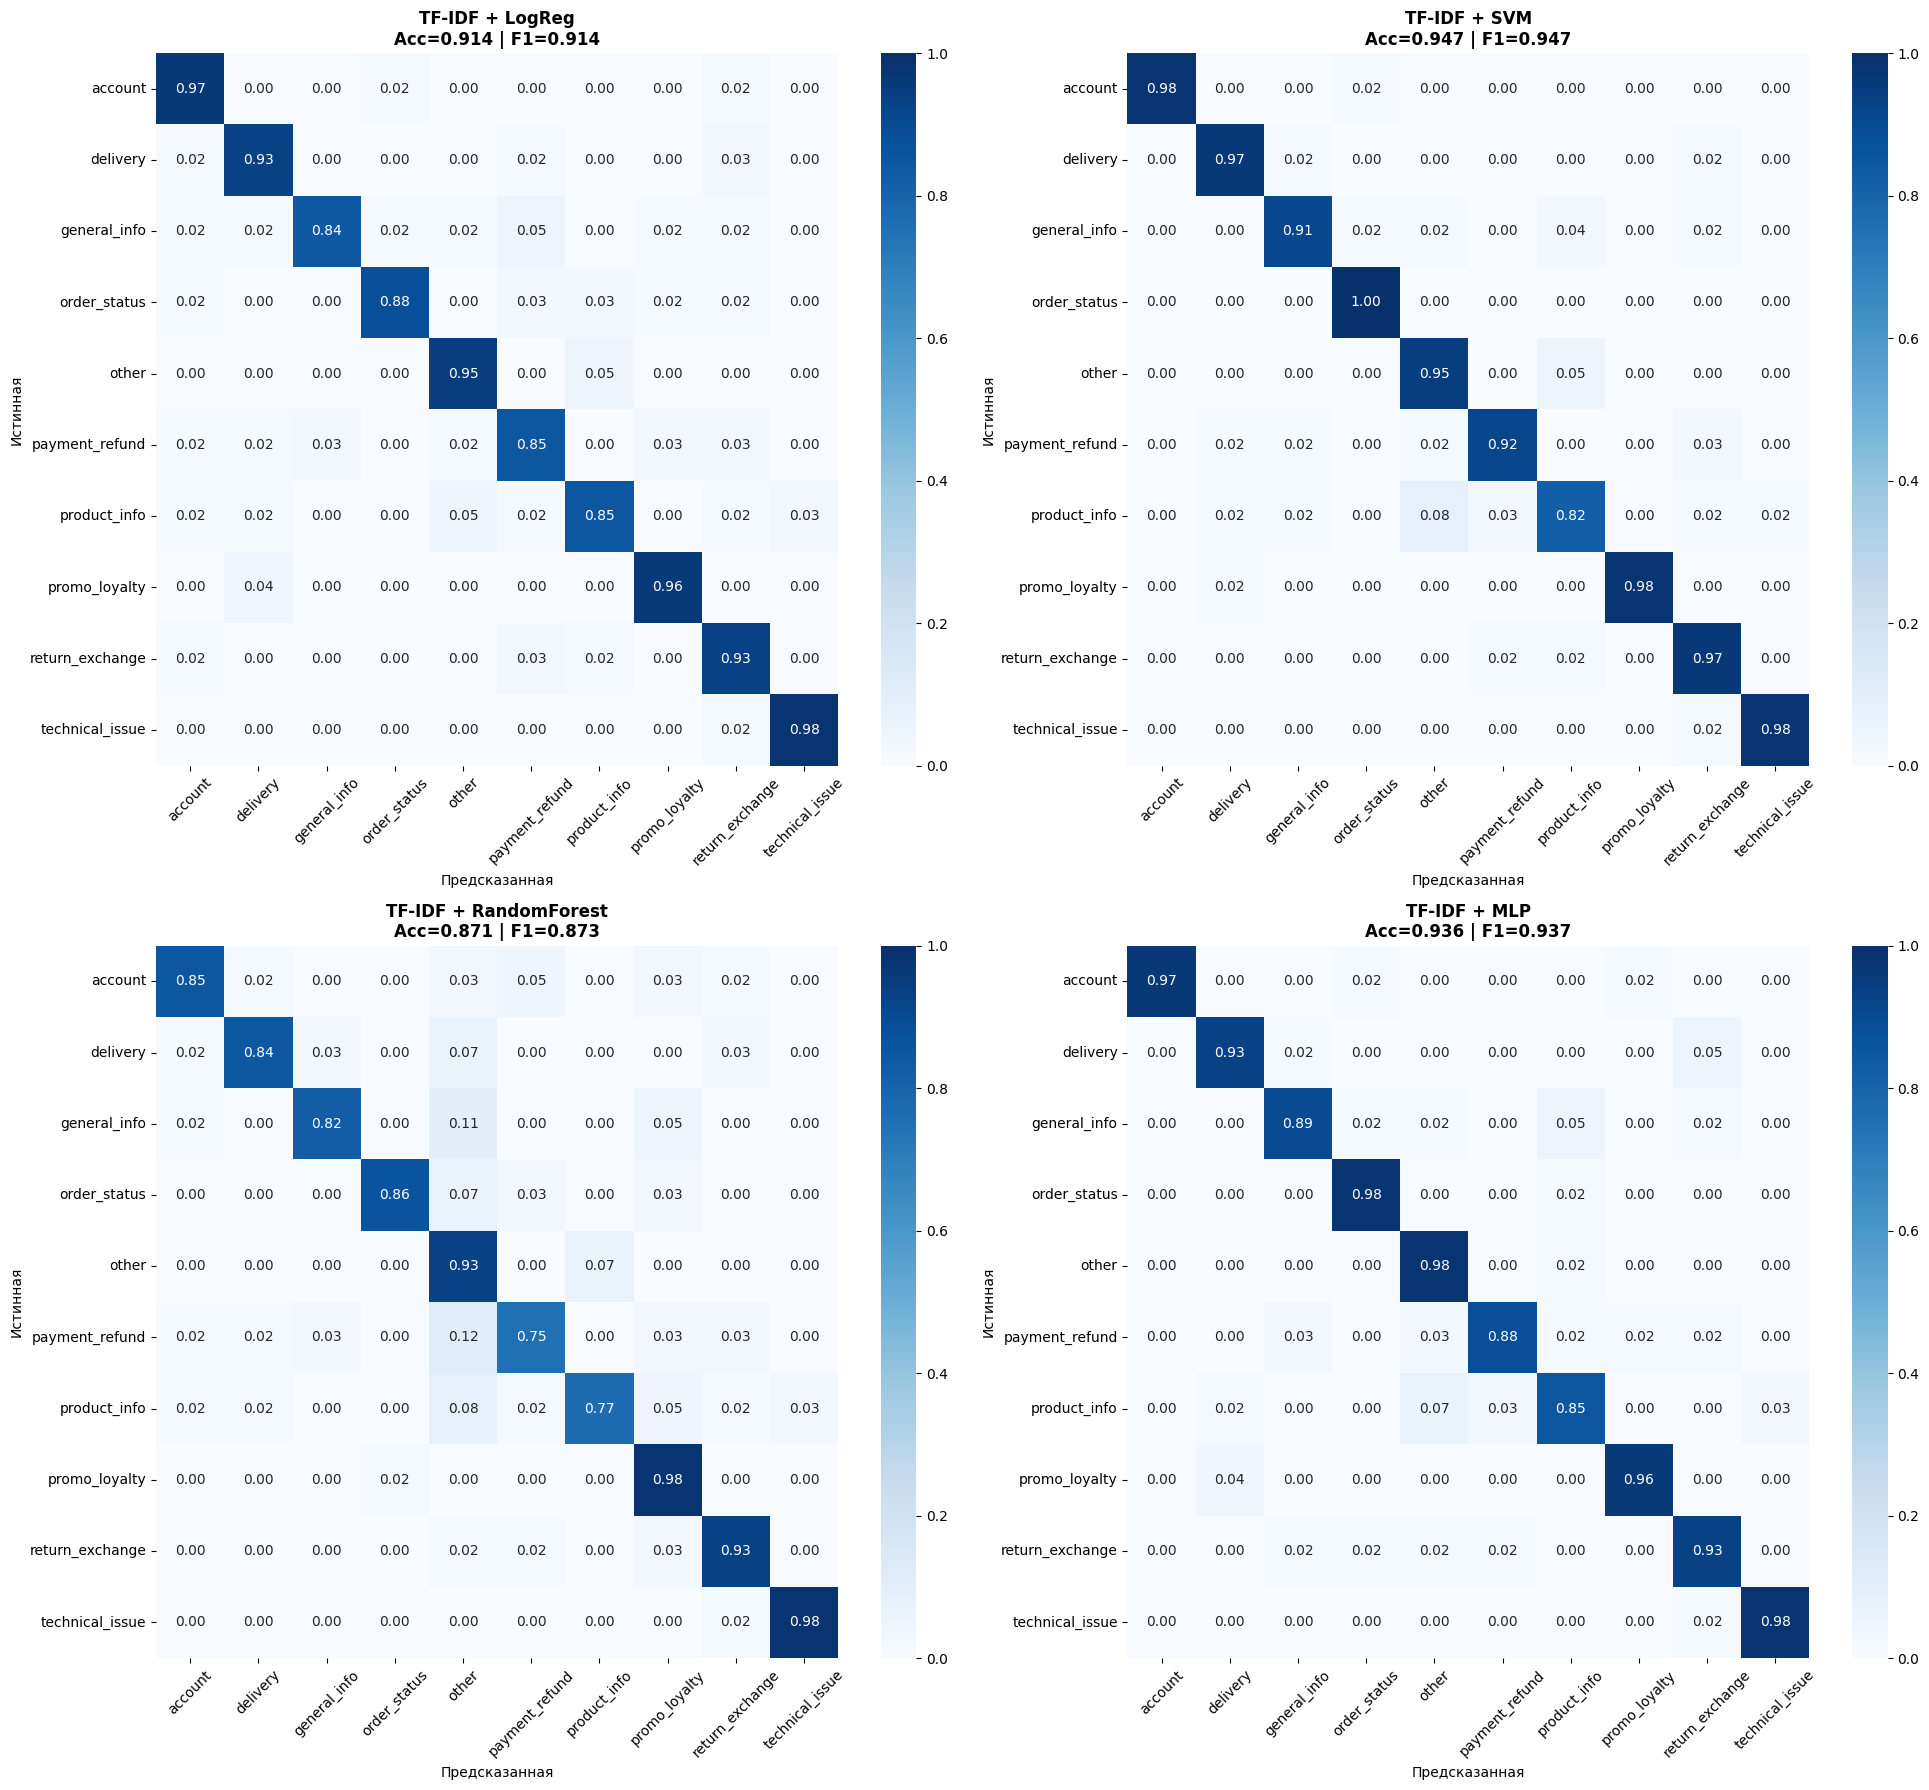

✅ Сохранено: results/baseline_confusion_matrices.png
🔍 АНАЛИЗ ОШИБОК: TF-IDF + SVM

  account (ошибок: 1.7%)
    Путается с: order_status (1)

  delivery (ошибок: 3.4%)
    Путается с: general_info (1), return_exchange (1)

  general_info (ошибок: 8.8%)
    Путается с: order_status (1), other (1), product_info (2), return_exchange (1)

  order_status — без ошибок ✅

  other (ошибок: 5.1%)
    Путается с: product_info (3)

  payment_refund (ошибок: 8.3%)
    Путается с: delivery (1), general_info (1), other (1), return_exchange (2)

  product_info (ошибок: 18.3%)
    Путается с: delivery (1), general_info (1), other (5), payment_refund (2), return_exchange (1), technical_issue (1)

  promo_loyalty (ошибок: 1.9%)
    Путается с: delivery (1)

  return_exchange (ошибок: 3.4%)
    Путается с: payment_refund (1), product_info (1)

  technical_issue (ошибок: 1.8%)
    Путается с: return_exchange (1)


In [15]:
"""
Confusion Matrix для всех baseline моделей
"""
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

predictions = {
    "TF-IDF + LogReg": y_pred_lr,
    "TF-IDF + SVM": y_pred_svm,
    "TF-IDF + RandomForest": y_pred_rf,
    "TF-IDF + MLP": y_pred_mlp,
}

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx // 2, idx % 2]
    
    cm = confusion_matrix(y_test, y_pred, labels=CATEGORIES)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=CATEGORIES, yticklabels=CATEGORIES,
        ax=ax, vmin=0, vmax=1
    )
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    ax.set_title(f"{name}\nAcc={acc:.3f} | F1={f1:.3f}", fontsize=12, fontweight='bold')
    ax.set_ylabel('Истинная')
    ax.set_xlabel('Предсказанная')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/baseline_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Сохранено: results/baseline_confusion_matrices.png")

"""
Анализ ошибок лучшей baseline модели
"""
# Берём лучшую baseline (определится из сводной таблицы)
best_name = best_baseline['Модель']
best_pred = predictions[best_name]

cm = confusion_matrix(y_test, best_pred, labels=CATEGORIES)

print(f"🔍 АНАЛИЗ ОШИБОК: {best_name}")
print(f"{'='*60}")

for i, true_cat in enumerate(CATEGORIES):
    errors = []
    for j, pred_cat in enumerate(CATEGORIES):
        if i != j and cm[i][j] > 0:
            errors.append(f"{pred_cat} ({cm[i][j]})")
    
    total = cm[i].sum()
    correct = cm[i][i]
    error_rate = (total - correct) / total * 100
    
    if errors:
        print(f"\n  {true_cat} (ошибок: {error_rate:.1f}%)")
        print(f"    Путается с: {', '.join(errors)}")
    else:
        print(f"\n  {true_cat} — без ошибок ✅")

In [17]:
"""
GridSearch для лучшей baseline модели
"""
print("=" * 60)
print("🔧 ПОДБОР ГИПЕРПАРАМЕТРОВ (TF-IDF + LogReg)")
print("=" * 60)

# Конвертация в numpy — решает ошибку с ArrowDtype
X_train_np = np.array(X_train.tolist())
y_train_np = np.array(y_train.tolist())

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'clf__C': [0.1, 1.0, 10.0],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train_np, y_train_np)
grid_time = time.time() - start

print(f"\n⏱️  Время GridSearch: {grid_time:.1f}s")
print(f"\n🏆 Лучшие параметры:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n📊 Лучший CV F1: {grid_search.best_score_:.3f}")

# Оценка на тесте
X_test_np = np.array(X_test.tolist())
y_pred_best = grid_search.predict(X_test_np)
acc_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best, average='macro')

print(f"\n📊 Test Accuracy: {acc_best:.3f}")
print(f"📊 Test Macro F1: {f1_best:.3f}")
print(f"\n{classification_report(y_test, y_pred_best, target_names=CATEGORIES, digits=3)}")

🔧 ПОДБОР ГИПЕРПАРАМЕТРОВ (TF-IDF + LogReg)
Fitting 5 folds for each of 27 candidates, totalling 135 fits

⏱️  Время GridSearch: 14.6s

🏆 Лучшие параметры:
   clf__C: 10.0
   tfidf__max_features: 10000
   tfidf__ngram_range: (1, 2)

📊 Лучший CV F1: 0.919

📊 Test Accuracy: 0.940
📊 Test Macro F1: 0.940

                 precision    recall  f1-score   support

        account      0.983     0.967     0.975        60
       delivery      0.949     0.966     0.957        58
   general_info      0.943     0.877     0.909        57
   order_status      0.967     1.000     0.983        59
          other      0.903     0.949     0.926        59
 payment_refund      0.885     0.900     0.893        60
   product_info      0.893     0.833     0.862        60
  promo_loyalty      0.981     0.962     0.971        53
return_exchange      0.919     0.966     0.942        59
technical_issue      0.982     0.982     0.982        56

       accuracy                          0.940       581
      macro 

📊 ФИНАЛЬНАЯ СВОДНАЯ ТАБЛИЦА: BASELINE vs ТРАНСФОРМЕРЫ
                 Модель         Тип  Accuracy  Macro F1 Время обучения
        TF-IDF + LogReg    Baseline     0.914     0.914           0.6s
           TF-IDF + SVM    Baseline     0.947     0.947           0.2s
  TF-IDF + RandomForest    Baseline     0.871     0.873           1.1s
           TF-IDF + MLP    Baseline     0.936     0.937          23.3s
TF-IDF + LogReg (tuned)    Baseline     0.940     0.940          14.6s
           rubert-tiny2 Transformer     0.943     0.944          45.9s
      rubert-base-cased Transformer     0.966     0.966          1289s


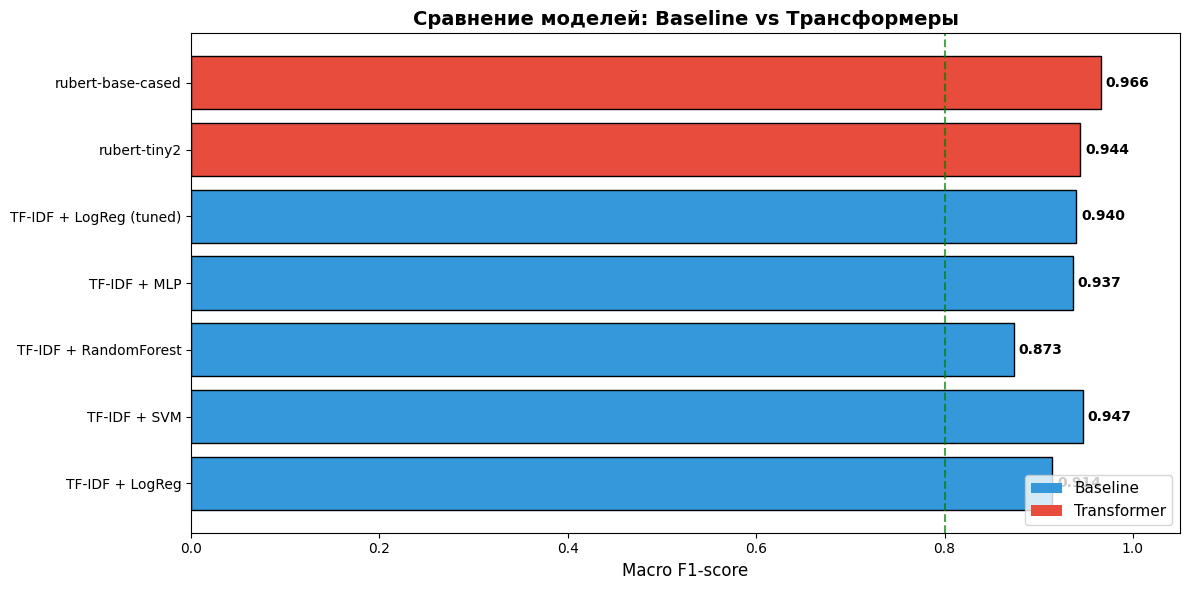

✅ Сохранено: results/all_models_comparison.png


In [18]:
"""
Сводная таблица: все модели
"""
# Метрики трансформеров (из предыдущих экспериментов)
all_results = pd.DataFrame([
    # Baseline
    {"Модель": "TF-IDF + LogReg",       "Тип": "Baseline", "Accuracy": acc_lr,    "Macro F1": f1_macro_lr,    "Время обучения": f"{train_time_lr:.1f}s"},
    {"Модель": "TF-IDF + SVM",          "Тип": "Baseline", "Accuracy": acc_svm,   "Macro F1": f1_macro_svm,   "Время обучения": f"{train_time_svm:.1f}s"},
    {"Модель": "TF-IDF + RandomForest",  "Тип": "Baseline", "Accuracy": acc_rf,    "Macro F1": f1_macro_rf,    "Время обучения": f"{train_time_rf:.1f}s"},
    {"Модель": "TF-IDF + MLP",          "Тип": "Baseline", "Accuracy": acc_mlp,   "Macro F1": f1_macro_mlp,   "Время обучения": f"{train_time_mlp:.1f}s"},
    {"Модель": "TF-IDF + LogReg (tuned)", "Тип": "Baseline", "Accuracy": acc_best, "Macro F1": f1_best,        "Время обучения": f"{grid_time:.1f}s"},
    # Трансформеры
    {"Модель": "rubert-tiny2",           "Тип": "Transformer", "Accuracy": 0.943,   "Macro F1": 0.944,         "Время обучения": "45.9s"},
    {"Модель": "rubert-base-cased",      "Тип": "Transformer", "Accuracy": 0.966,   "Macro F1": 0.966,         "Время обучения": "1289s"},
])

print("=" * 80)
print("📊 ФИНАЛЬНАЯ СВОДНАЯ ТАБЛИЦА: BASELINE vs ТРАНСФОРМЕРЫ")
print("=" * 80)
print(all_results.to_string(index=False, float_format="%.3f"))

# Визуализация
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#3498db' if t == 'Baseline' else '#e74c3c' for t in all_results['Тип']]

bars = ax.barh(all_results['Модель'], all_results['Macro F1'], color=colors, edgecolor='black')

ax.set_xlabel('Macro F1-score', fontsize=12)
ax.set_title('Сравнение моделей: Baseline vs Трансформеры', fontsize=14, fontweight='bold')
ax.axvline(x=0.80, color='green', linestyle='--', alpha=0.7, label='NFR порог (0.80)')

# Значения на барах
for bar, val in zip(bars, all_results['Macro F1']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')

ax.legend()
ax.set_xlim(0, 1.05)

# Легенда цветов
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Baseline'),
    Patch(facecolor='#e74c3c', label='Transformer'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('../results/all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Сохранено: results/all_models_comparison.png")

In [19]:
"""
Сохранение всех результатов
"""
all_results.to_csv("../results/all_models_comparison.csv", index=False)

print("✅ Все результаты сохранены:")
print("   results/baseline_confusion_matrices.png")
print("   results/all_models_comparison.png")
print("   results/all_models_comparison.csv")
print(f"\n🏆 Лучшая baseline: {best_baseline['Модель']} (F1: {best_baseline['Macro F1']:.3f})")
print(f"🏆 Лучший трансформер: rubert-base-cased (F1: 0.966)")
print(f"📈 Прирост трансформера над baseline: +{(0.966 - best_baseline['Macro F1']):.3f} F1")

✅ Все результаты сохранены:
   results/baseline_confusion_matrices.png
   results/all_models_comparison.png
   results/all_models_comparison.csv

🏆 Лучшая baseline: TF-IDF + SVM (F1: 0.947)
🏆 Лучший трансформер: rubert-base-cased (F1: 0.966)
📈 Прирост трансформера над baseline: +0.019 F1
